# Spectral Grids — documentation examples

Companion notebook to the **Spectral Grids** documentation page
(`docs/source/spectral_grids.rst`). One section per code snippet.

Instead of downloading a real atmosphere grid, this notebook **builds a tiny
synthetic zarr grid** (blackbody-like spectra over a teff x logg lattice), so
it runs anywhere with the `[grid]` extra installed
(`pip install "stellar-spice[grid]"`).

In [1]:
%matplotlib inline
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Build a tiny synthetic grid

A grid is a zarr store with `wavelength`, `flux`, `continuum`, `params`, and
`param_names` arrays — one flux/continuum row per parameter combination. We
also write a `geometry` array so the provenance section below has something
to read.

In [2]:
import tempfile
from pathlib import Path
import zarr

store_path = Path(tempfile.mkdtemp()) / "tiny_grid.zarr"

teffs = np.array([5000., 5500., 6000., 6500.])
loggs = np.array([2.0, 3.0, 4.0, 5.0])
wavelength = np.linspace(4900., 5100., 400)

rows, geometry = [], []
for teff in teffs:
    for logg in loggs:
        rows.append([teff, logg])
        geometry.append("spherical" if logg < 3.0 else "plane_parallel")
params = np.array(rows)

# Blackbody-like continua with one artificial teff-dependent line at 5000 A
h, c, k = 6.626e-27, 2.998e10, 1.381e-16
wl_cm = wavelength * 1e-8
def planck(teff):
    return (2*h*c**2 / wl_cm**5) / (np.expm1(h*c / (wl_cm*k*teff))) * 1e-8

continuum = np.stack([planck(t) for t, _ in params])
line = 1.0 - 0.4 * np.exp(-0.5*((wavelength - 5000.0)/0.8)**2)
flux = continuum * line[None, :]

group = zarr.open_group(str(store_path), mode="w")
group.create_array("wavelength", data=wavelength)
group.create_array("flux", data=flux)
group.create_array("continuum", data=continuum)
group.create_array("params", data=params)
group.create_array("param_names", data=np.asarray(["teff", "logg"], dtype="S"))
group.create_array("geometry", data=np.asarray(geometry, dtype="S"))
print("wrote", store_path, "with", params.shape[0], "nodes")

wrote /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/tmpbrkkqogl/tiny_grid.zarr with 16 nodes


/Users/mjablons/anaconda3/lib/python3.11/site-packages/zarr/core/dtype/npy/bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=4)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/Users/mjablons/anaconda3/lib/python3.11/site-packages/zarr/core/dtype/npy/bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=14)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be 

## Generate the index

On the command line this is
`python -m spice.spectrum.generate_zarr_index <grid> --exclude-mu`;
here we call the same function directly.

In [3]:
from spice.spectrum.generate_zarr_index import write_index_parquet

index_path = write_index_parquet(store_path, include_mu=False)
print("index written to", index_path)

index written to /private/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/tmpbrkkqogl/tiny_grid.zarr/index.parquet


## Load and query the grid

[spice] pandas loaded in 0.8 s
[spice] Building sparse grid index...
[spice] Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.3 s


/Users/mjablons/anaconda3/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


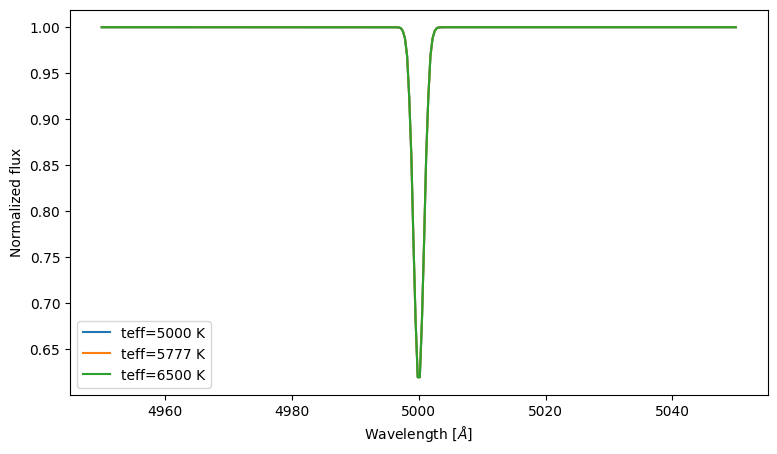

In [4]:
from spice.spectrum import FluxLazyZarrInterpolator

interp = FluxLazyZarrInterpolator(str(store_path), params=["teff", "logg"])

log_wavelengths = jnp.log10(jnp.linspace(4950., 5050., 300))

# Interpolated at an off-node point — the result has shape (n_wavelengths, 2):
# [flux, continuum]
spec = interp.flux(log_wavelengths, interp.to_parameters({"teff": 5777., "logg": 4.44}))

fig, ax = plt.subplots(figsize=(9, 5))
for teff in [5000., 5777., 6500.]:
    s = interp.flux(log_wavelengths, interp.to_parameters({"teff": teff, "logg": 4.44}))
    ax.plot(10**log_wavelengths, s[:, 0] / s[:, 1], label=f"teff={teff:.0f} K")
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel("Normalized flux")
ax.legend()
plt.show()

## Use the grid in mesh synthesis

The interpolator's `intensity` plugs straight into `simulate_observed_flux`
(here with the flux-conservation limb-darkening of
`FluxLazyZarrInterpolator`). Mesh parameters must be ordered like the
interpolator's parameters.

In [5]:
from spice.models import IcosphereModel
from spice.spectrum import simulate_observed_flux

mesh = IcosphereModel.construct(500, 1., 1.,
                                interp.to_parameters({"teff": 5777., "logg": 4.44}),
                                interp.parameter_names)

observed = simulate_observed_flux(interp.intensity, mesh, log_wavelengths)
print("observed spectrum shape:", observed.shape)

[spice] IcosphereModel constructed in 0.7 s
observed spectrum shape: (300, 2)


## Geometry provenance

The index records each node's radiative-transfer geometry; it is provenance
only — never an interpolation axis — and lets you detect queries that
straddle the plane-parallel/spherical boundary.

In [6]:
print("per-node geometry:", interp.geometry[:6], "...")

query = {"teff": 5777., "logg": 2.5}  # straddles the logg = 3 boundary
import numpy as np
node_geoms = set(np.asarray(interp.geometry)[
    (params[:, 1] >= 2.0) & (params[:, 1] <= 3.0)
])
print(f"query {query} interpolates across geometries: {node_geoms}")

per-node geometry: ['spherical' 'plane_parallel' 'plane_parallel' 'plane_parallel'
 'spherical' 'plane_parallel'] ...
query {'teff': 5777.0, 'logg': 2.5} interpolates across geometries: {'spherical', 'plane_parallel'}
